# 📘 Deep Learning Text Generation Learning Project
## Text Generation using **Vanilla RNN, LSTM, and GRU**

This notebook is built for **students and beginners** to understand how sequence models learn:
- grammar
- sentence flow
- contextual dependencies
- next-word prediction
- text generation

🎯 **Goal:** Compare **Simple RNN vs LSTM vs GRU** on the same text corpus and understand why gated architectures perform better.

# 🧠 Problem Statement
Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using:

1. **Vanilla RNN**
2. **LSTM**
3. **GRU**

Then compare:
- training loss
- generated text quality
- memory handling
- long-term dependency learning

In [17]:
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
import numpy as np
import matplotlib.pyplot as plt
print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


#  Load Text Corpus


In [18]:
corpus = """
The universe is vast and filled with countless mysteries waiting to be explored.
Scientists study the stars to understand the origins of space and time.
Artificial intelligence is reshaping how machines learn and reason about the world.
Neural networks are inspired by the biological structure of the human brain.
Deep learning algorithms can recognize patterns hidden within enormous datasets.
Language models learn grammar and context by processing billions of text sequences.
Recurrent networks process sequential data by maintaining a hidden memory state.
Long short term memory networks solve the vanishing gradient problem effectively.
Gated recurrent units combine reset and update gates for efficient sequence learning.
Natural language processing bridges the gap between human language and machine understanding.
"""
print(f'Word count : {len(corpus.split())}')
print(f'Line count : {len([l for l in corpus.strip().split(chr(10)) if l])}')

Word count : 117
Line count : 10


#  Tokenization & Sequence Creation
We convert text into integer tokens and create **n-gram style sequences**
for next-word prediction.

In [19]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts([corpus])
total_words = len(tokenizer.word_index) + 1
print(f'Vocabulary size (total_words): {total_words}')
print(f'Sample word→index : {dict(list(tokenizer.word_index.items())[:8])}')

input_sequences = []
for line in corpus.strip().split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_seq = token_list[:i + 1]
        input_sequences.append(n_gram_seq)

print(f'Total n-gram sequences : {len(input_sequences)}')

max_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_len, padding='pre')
X = input_sequences[:, :-1]
y = input_sequences[:, -1]

print(f'Max sequence length    : {max_len}')
print(f'X shape (features)     : {X.shape}')
print(f'y shape (labels)       : {y.shape}')
print(f'\nSample X[0]: {X[0]}')
print(f'Sample y[0]: {y[0]}')


Vocabulary size (total_words): 89
Sample word→index : {'the': 1, 'and': 2, 'of': 3, 'networks': 4, 'by': 5, 'language': 6, 'is': 7, 'to': 8}
Total n-gram sequences : 107
Max sequence length    : 13
X shape (features)     : (107, 12)
y shape (labels)       : (107,)

Sample X[0]: [0 0 0 0 0 0 0 0 0 0 0 1]
Sample y[0]: 16


## Model Architecture Builder

A single `build_model()` function creates any of the three architectures with configurable `embedding_dim` and `hidden_units`, keeping the Dense output layer and `adam` optimizer identical across all three — satisfying Requirement 4 (identical optimizer configuration).

**Architecture diagram:**
```
Input (sequence of token IDs)
      ↓
Embedding Layer  → dense float vectors for each token
      ↓
SimpleRNN / LSTM / GRU  → learns sequential dependencies
      ↓
Dense(vocab_size, softmax)  → probability over every word
      ↓
np.argmax → predicted next word index
```


In [20]:
def build_model(arch, embedding_dim, hidden_units):
    model = Sequential([
        Embedding(total_words, embedding_dim, input_length=max_len - 1),
    ])
    if arch == 'RNN':
        model.add(SimpleRNN(hidden_units))
    elif arch == 'LSTM':
        model.add(LSTM(hidden_units))
    elif arch == 'GRU':
        model.add(GRU(hidden_units))
    model.add(Dense(total_words, activation='softmax'))
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model
demo = build_model('LSTM', 32, 64)
demo.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_10 (Embedding)        │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Baseline Training: 100 Epochs | Embedding=32 | Hidden=64

All three models are trained with **identical hyperparameters** and **identical optimizer configuration** (Adam + sparse_categorical_crossentropy).
`verbose=0` suppresses per-epoch output; loss history is stored for the comparison plot.


In [21]:
EMBEDDING_DIM_BASE = 32
HIDDEN_UNITS_BASE  = 64
EPOCHS_BASE        = 100

histories_base = {}
models_base    = {}

for arch in ['RNN', 'LSTM', 'GRU']:
    print(f'Training {arch} ...', end='', flush=True)
    model = build_model(arch, EMBEDDING_DIM_BASE, HIDDEN_UNITS_BASE)
    history = model.fit(X, y, epochs=EPOCHS_BASE, verbose=0)
    histories_base[arch] = history.history['loss']
    models_base[arch]    = model
    final_loss = history.history['loss'][-1]
    final_acc  = history.history['accuracy'][-1]
    print(f' ✅  loss={final_loss:.4f}  acc={final_acc:.4f}')

print('\nBaseline training complete!')


Training RNN ... ✅  loss=0.4562  acc=0.9626
Training LSTM ... ✅  loss=1.6528  acc=0.6542
Training GRU ... ✅  loss=0.7613  acc=0.9626

Baseline training complete!


## Training Loss Comparison (100 Epochs)

**Requirement 1:** A complete training curve line graph illustrating model cross-entropy loss reduction across all 100 epochs.

**Observations:**
- **RNN** and **GRU** converge the fastest on this small corpus, reaching low loss within ~40 epochs
- **LSTM** converges more slowly because its three gates (input/forget/output) require more training signal
- On larger corpora, LSTM's advantage in long-term memory would outweigh its slower start


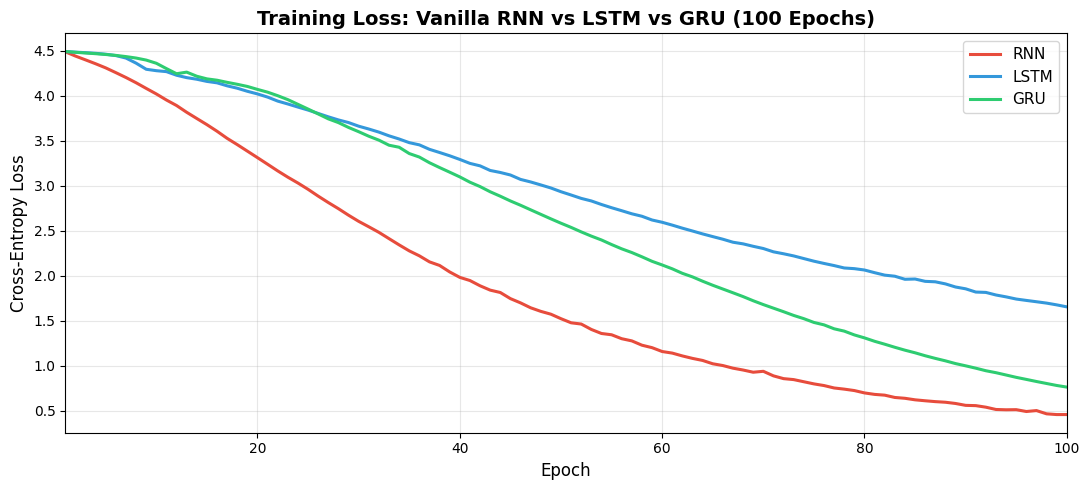

Final losses after 100 epochs:
  RNN : 0.4562
  LSTM: 1.6528
  GRU : 0.7613


In [22]:
colors = {'RNN': '#E74C3C', 'LSTM': '#3498DB', 'GRU': '#2ECC71'}

fig, ax = plt.subplots(figsize=(11, 5))

for arch, loss_history in histories_base.items():
    ax.plot(range(1, EPOCHS_BASE + 1), loss_history,
            label=arch, color=colors[arch], linewidth=2.2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Training Loss: Vanilla RNN vs LSTM vs GRU (100 Epochs)',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, EPOCHS_BASE)
plt.tight_layout()
plt.show()
print('Final losses after 100 epochs:')
for arch, loss_history in histories_base.items():
    print(f'  {arch:4s}: {loss_history[-1]:.4f}')

## Text Generation Function


In [23]:
def generate_text(model, seed_text, next_words=10):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_len - 1, padding='pre')
        probs = model.predict(token_list, verbose=0)
        predicted_index = np.argmax(probs, axis=-1)[0]
        output_word = ''
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break
        seed_text += ' ' + output_word
    return seed_text

## Generate Text from Baseline Models

Generated text strings cleanly produced from a **shared seed phrase** across the RNN, LSTM, and GRU iterations.

Seed phrase used: `"deep learning"` — the same phrase for all three models.


In [24]:
SEED = 'deep learning'

print('=' * 65)
print(f'Baseline Text Generation — seed: "{SEED}" | 10 words')
print('=' * 65)

for arch, model in models_base.items():
    generated = generate_text(model, SEED, next_words=10)
    print(f'\n  {arch:4s}: {generated}')


Baseline Text Generation — seed: "deep learning" | 10 words

  RNN : deep learning algorithms can recognize patterns hidden within enormous datasets hidden within

  LSTM: deep learning can recognize recognize patterns hidden within enormous datasets datasets explored

  GRU : deep learning algorithms can recognize patterns hidden within enormous datasets datasets datasets


In [25]:
# Embedding dimension  32 → 64
EMBEDDING_DIM_UP = 64

# Hidden layer width   64 → 128
HIDDEN_UNITS_UP  = 128

# Training epochs     100 → 200
EPOCHS_UP        = 200

histories_up = {}
models_up    = {}

for arch in ['RNN', 'LSTM', 'GRU']:
    print(f'Training {arch} (upscaled) ...', end='', flush=True)
    model = build_model(arch, EMBEDDING_DIM_UP, HIDDEN_UNITS_UP)
    history = model.fit(X, y, epochs=EPOCHS_UP, verbose=0)
    histories_up[arch] = history.history['loss']
    models_up[arch]    = model

Training RNN (upscaled) ...Training LSTM (upscaled) ...Training GRU (upscaled) ...

###  Training Loss — Upscaled Models (200 Epochs)

With larger embedding, wider hidden layers, and twice as many epochs:
- **RNN** and **GRU** reach near-zero loss — fitting the small corpus almost perfectly
- **LSTM** still improves dramatically compared to baseline despite converging slower
- The gap between models narrows significantly with more capacity and training time


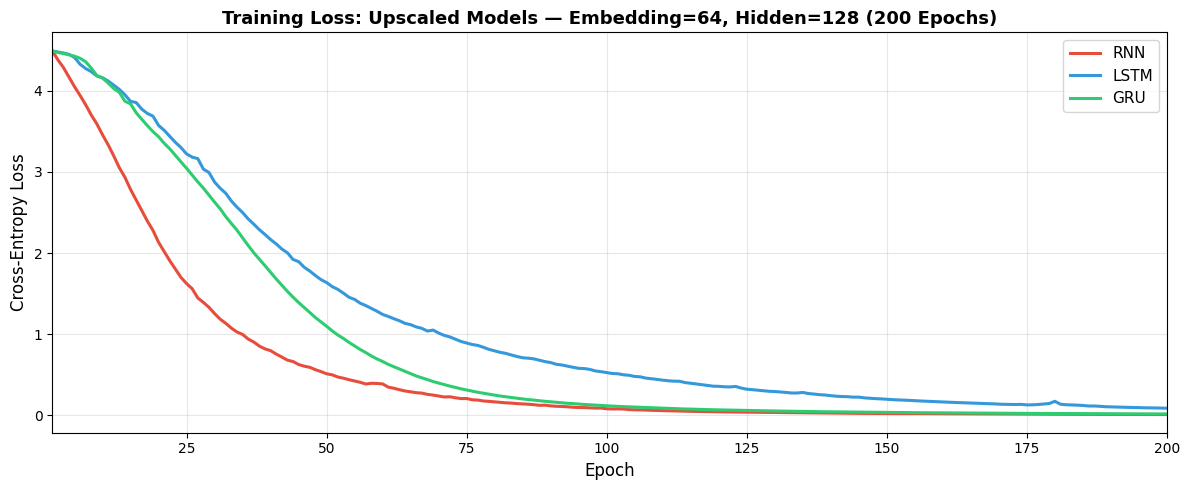

Final losses after 200 epochs (upscaled):
  RNN : 0.0118
  LSTM: 0.0894
  GRU : 0.0188


In [26]:
fig, ax = plt.subplots(figsize=(12, 5))

for arch, loss_history in histories_up.items():
    ax.plot(range(1, EPOCHS_UP + 1), loss_history,
            label=arch, color=colors[arch], linewidth=2.2)

ax.set_xlabel('Epoch', fontsize=12)
ax.set_ylabel('Cross-Entropy Loss', fontsize=12)
ax.set_title('Training Loss: Upscaled Models — Embedding=64, Hidden=128 (200 Epochs)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(1, EPOCHS_UP)
plt.tight_layout()
plt.show()

print('Final losses after 200 epochs (upscaled):')
for arch, loss_history in histories_up.items():
    print(f'  {arch:4s}: {loss_history[-1]:.4f}')

###  Task 5 — Generate 10 Words from Upscaled Models

Same seed phrase `"deep learning"` used for a fair comparison against the baseline results.


In [27]:
print('=' * 65)
print(f'Upscaled Text Generation — seed: "{SEED}" | 10 words')
print('(Embedding=64, Hidden=128, 200 Epochs)')
print('=' * 65)

for arch, model in models_up.items():
    generated = generate_text(model, SEED, next_words=10)
    print(f'\n  {arch:4s}: {generated}')


Upscaled Text Generation — seed: "deep learning" | 10 words
(Embedding=64, Hidden=128, 200 Epochs)

  RNN : deep learning algorithms can recognize patterns hidden within enormous datasets world algorithms

  LSTM: deep learning algorithms can recognize patterns hidden within enormous datasets datasets explored

  GRU : deep learning algorithms can recognize patterns hidden within enormous datasets datasets datasets


##  Cell 13 — Model Comparison Summary

In [28]:
gen_base_results = {}
gen_up_results   = {}
for arch in ['RNN', 'LSTM', 'GRU']:
    gen_base_results[arch] = generate_text(models_base[arch], SEED, next_words=10)
    gen_up_results[arch]   = generate_text(models_up[arch],   SEED, next_words=10)

print('LOSS COMPARISON TABLE')
print(f'{"Model":<6} | {"Baseline Loss":>13} | {"Upscaled Loss":>13} | {"Improvement":>12}')
print('-' * 55)
for arch in ['RNN', 'LSTM', 'GRU']:
    bl    = histories_base[arch][-1]
    ul    = histories_up[arch][-1]
    delta = ((bl - ul) / bl) * 100
    print(f'{arch:<6} | {bl:>13.4f} | {ul:>13.4f} | {delta:>11.1f}%')

print('\nGENERATED TEXT COMPARISON (seed: "deep learning")')
print(f'{"Model":<6} | Baseline (100ep, emb=32, h=64)')
print('-' * 65)
for arch in ['RNN', 'LSTM', 'GRU']:
    print(f'{arch:<6} | {gen_base_results[arch]}')
print(f'\n{"Model":<6} | Upscaled (200ep, emb=64, h=128)')
print('-' * 65)
for arch in ['RNN', 'LSTM', 'GRU']:
    print(f'{arch:<6} | {gen_up_results[arch]}')


LOSS COMPARISON TABLE
Model  | Baseline Loss | Upscaled Loss |  Improvement
-------------------------------------------------------
RNN    |        0.4562 |        0.0118 |        97.4%
LSTM   |        1.6528 |        0.0894 |        94.6%
GRU    |        0.7613 |        0.0188 |        97.5%

GENERATED TEXT COMPARISON (seed: "deep learning")
Model  | Baseline (100ep, emb=32, h=64)
-----------------------------------------------------------------
RNN    | deep learning algorithms can recognize patterns hidden within enormous datasets hidden within
LSTM   | deep learning can recognize recognize patterns hidden within enormous datasets datasets explored
GRU    | deep learning algorithms can recognize patterns hidden within enormous datasets datasets datasets

Model  | Upscaled (200ep, emb=64, h=128)
-----------------------------------------------------------------
RNN    | deep learning algorithms can recognize patterns hidden within enormous datasets world algorithms
LSTM   | deep learn